In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2, RealAmplitudes
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_ibm_runtime.fake_provider.fake_backend import FakeBackendV2
from qiskit.providers import Backend

## Qubit count scaling

In [3]:
def fcc_no_slack(n: int) -> int:
    return int(4 * n - 10 + 1 - 3 * n / 2 + n ** 2 / 2)

def fcc_slack(n: int) -> int:
    num_slack_qubits = 0
    for i in range(n - 3):
        for j in range(i + 3, n):
            num_slack_qubits += np.ceil(2 * np.log2(j - i))
    return int(4 * n - 10 + 1 - 3 * n / 2 + n ** 2 / 2 + num_slack_qubits)

def tetrahedral(n: int) -> int:
    return int(2 * (n - 3) - 1 + ((n - 4) ** 2 - np.mod(n - 6, 2) ** 2) / 4)

In [4]:
for n in range(5, 11):
    print(f"n = {n}")
    print(f"tetrahedral = {tetrahedral(n)}")
    print(f"fcc_no_slack = {fcc_no_slack(n)}")
    print(f"fcc_slack = {fcc_slack(n)}")
    print()

n = 5
tetrahedral = 3
fcc_no_slack = 16
fcc_slack = 28

n = 6
tetrahedral = 6
fcc_no_slack = 24
fcc_slack = 49

n = 7
tetrahedral = 9
fcc_no_slack = 33
fcc_slack = 77

n = 8
tetrahedral = 13
fcc_no_slack = 43
fcc_slack = 112

n = 9
tetrahedral = 17
fcc_no_slack = 54
fcc_slack = 154

n = 10
tetrahedral = 22
fcc_no_slack = 66
fcc_slack = 204



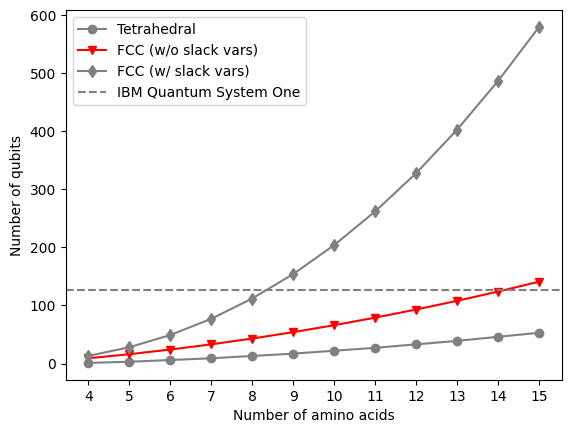

In [5]:
# Plot the number of qubits required for the different lattice approaches as a function of number of amino acids
n = np.arange(4, 16, 1)
plt.plot(n, [tetrahedral(i) for i in n], label="Tetrahedral", marker='o', color='gray')
plt.plot(n, [fcc_no_slack(i) for i in n], label="FCC (w/o slack vars)", marker='v', color='r')
plt.plot(n, [fcc_slack(i) for i in n], label="FCC (w/ slack vars)", marker='d', color='gray')
plt.xticks(n)
plt.xlabel("Number of amino acids")
plt.ylabel("Number of qubits")
plt.axhline(127, color='gray', linestyle='--', label="IBM Quantum System One")
plt.legend()
plt.show()

## Circuit/gate depth scalings

For the following analysis, an approach on FCC lattice *without* using slack variables is assumed. Technically, we currently have two options for such implementation: 
1. using high-degree polynomials to represent the non-overlapping constraints, which are directly added to the Hamiltonian; 
2. introducing Lagrange multipliers to represent the non-overlapping constraints, which can be embedded into the VQE framework without leading to an exponential increase in the number of Hamiltonian terms.

Both approaches lead to the same qubit count as well as the same circuit depth for a given ansatz. Below we will focus on a type of hardware efficient ansatz that we have been testing. We will also assume a fixed number of layers for all problem sizes, which may not be a reasonable assumption in practice.

In [6]:
def transpile_ansatz(
    ansatz_type: str,
    entanglement: str,
    num_layers: int,
    backend: FakeBackendV2 | Backend,
    transpilation_repetitions: int = 10,
) -> tuple[dict, dict]:
    """
    Create a dictionary of circuit depths and ECR depths for the given ansatz and backend.

    Args:
        ansatz_type (str): The ansatz to transpile. Options: "EfficientSU2" or "RealAmplitdues".
        entanglement (str): The entanglement pattern, e.g., "linear" vs. "pairwise".
        backend (FakeBackendV2 | Backend): The backend to transpile the ansatz on.

    Returns:
        tuple[dict, dict]: A tuple of dictionaries containing the circuit depths and ECR depths for the ansatz.
    """
    # Setup empty dictionaries (compare unoptimized and most optimized)
    circ_depths_ansatz: dict[str, list] = {"opt_0": [], "opt_3": []}
    ecr_depths_ansatz: dict[str, list] = {"opt_0": [], "opt_3": []}

    # We will transpile the same circuit multiple times and choose the best result to save due to the stochastic nature of the transpiler
    for n in range(4, 15):
        print(f"num AAs = {n}")
        num_qubits = fcc_no_slack(n)
        print(f"num qubits = {num_qubits}")

        if ansatz_type == "EfficientSU2":
            ansatz = EfficientSU2(
                num_qubits, reps=num_layers, entanglement=entanglement
            )
        elif ansatz_type == "RealAmplitudes":
            ansatz = RealAmplitudes(
                num_qubits, reps=num_layers, entanglement=entanglement
            )
        else:
            raise ValueError("Ansatz not supported yet.")

        opt_0_circ_depth, opt_0_ecr_depth = np.inf, np.inf
        for _ in range(transpilation_repetitions):
            opt_0_circ = transpile(ansatz, backend, optimization_level=0)
            circ_depth = opt_0_circ.depth()
            ecr_depth = opt_0_circ.depth(filter_function=lambda x: x[0].name == "ecr")
            if circ_depth < opt_0_circ_depth:
                opt_0_circ_depth = circ_depth
            if ecr_depth < opt_0_ecr_depth:
                opt_0_ecr_depth = ecr_depth
        circ_depths_ansatz["opt_0"].append(opt_0_circ_depth)
        ecr_depths_ansatz["opt_0"].append(opt_0_ecr_depth)
        print(f"Opt 0: Circ depth = {opt_0_circ_depth}, ECR depth = {opt_0_ecr_depth}")

        opt_3_circ_depth, opt_3_ecr_depth = np.inf, np.inf
        for _ in range(transpilation_repetitions):
            opt_3_circ = transpile(ansatz, backend, optimization_level=3)
            circ_depth = opt_3_circ.depth()
            ecr_depth = opt_3_circ.depth(filter_function=lambda x: x[0].name == "ecr")
            if circ_depth < opt_3_circ_depth:
                opt_3_circ_depth = circ_depth
            if ecr_depth < opt_3_ecr_depth:
                opt_3_ecr_depth = ecr_depth
        circ_depths_ansatz["opt_3"].append(opt_3_circ_depth)
        ecr_depths_ansatz["opt_3"].append(opt_3_ecr_depth)
        print(f"Opt 3: Circ depth = {opt_3_circ_depth}, ECR depth = {opt_3_ecr_depth}")
        print()
    return circ_depths_ansatz, ecr_depths_ansatz

In [ ]:
backend = FakeSherbrooke()

# ESU2 with linear entanglement
circ_depths_esu2_linear, ecr_depths_esu2_linear = transpile_ansatz("EfficientSU2", "linear", 2, backend)

# ESU2 with pairwise entanglement
circ_depths_esu2_pairwise, ecr_depths_esu2_pairwise = transpile_ansatz("EfficientSU2", "pairwise", 2, backend)

num AAs = 4
num qubits = 9
Opt 0: Circ depth = 102, ECR depth = 10
Opt 3: Circ depth = 69, ECR depth = 10

num AAs = 5
num qubits = 16
Opt 0: Circ depth = 231, ECR depth = 47
Opt 3: Circ depth = 90, ECR depth = 17

num AAs = 6
num qubits = 24
Opt 0: Circ depth = 469, ECR depth = 103
Opt 3: Circ depth = 137, ECR depth = 25

num AAs = 7
num qubits = 33
Opt 0: Circ depth = 543, ECR depth = 112


In [60]:
# Save the results into a json file
import json
with open("fcc_transpilation_results.json", "w") as f:
    json.dump(
        {
            "circ_depths_esu2_linear": circ_depths_esu2_linear,
            "ecr_depths_esu2_linear": ecr_depths_esu2_linear,
            "circ_depths_esu2_pairwise": circ_depths_esu2_pairwise,
            "ecr_depths_esu2_pairwise": ecr_depths_esu2_pairwise,
        },
        f,
    )

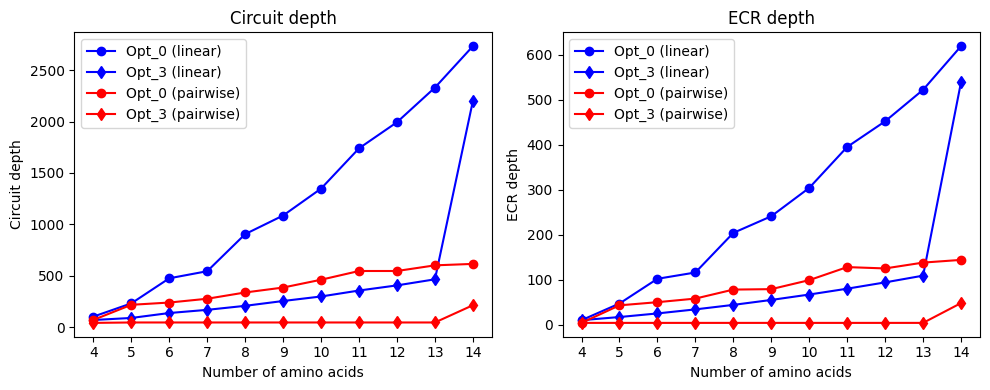

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
num_AAs = range(4, 15)
ax[0].plot(num_AAs, circ_depths_esu2_linear["opt_0"], label="Opt_0 (linear)", marker='o', color='b')
ax[0].plot(num_AAs, circ_depths_esu2_linear["opt_3"], label="Opt_3 (linear)", marker='d', color='b')
ax[0].plot(num_AAs, circ_depths_esu2_pairwise["opt_0"], label="Opt_0 (pairwise)", marker='o', color='r')
ax[0].plot(num_AAs, circ_depths_esu2_pairwise["opt_3"], label="Opt_3 (pairwise)", marker='d', color='r')
ax[0].set_ylabel("Circuit depth")
ax[0].set_xticks(num_AAs)
ax[0].set_xlabel("Number of amino acids")
ax[0].legend()
ax[0].set_title("Circuit depth")

ax[1].plot(num_AAs, ecr_depths_esu2_linear["opt_0"], label="Opt_0 (linear)", marker='o', color='b')
ax[1].plot(num_AAs, ecr_depths_esu2_linear["opt_3"], label="Opt_3 (linear)", marker='d', color='b')
ax[1].plot(num_AAs, ecr_depths_esu2_pairwise["opt_0"], label="Opt_0 (pairwise)", marker='o', color='r')
ax[1].plot(num_AAs, ecr_depths_esu2_pairwise["opt_3"], label="Opt_3 (pairwise)", marker='d', color='r')
ax[1].set_ylabel("ECR depth")
ax[1].set_xticks(num_AAs)
ax[1].set_xlabel("Number of amino acids")
ax[1].legend()
ax[1].set_title("ECR depth")

plt.tight_layout()
plt.show()

## Number of Hamiltonian terms scaling

We compare the number of Hamiltonian terms for the two approaches mentioned above. The number of terms in the Hamiltonian is proportional to the number of constraints in the problem. For the high-degree polynomial approach, the number of terms scales as $O(2^d)$, where $d$ is the degree of the polynomial. Note that the degree required scales linearly with the number of amino acids $N$, so the number of terms scales as $O(2^N)$.

For the Lagrange multiplier approach, the number of terms scales polynomially with $N$.

In [3]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from time import time

/Users/ruihaoli/protein-folding-qc/notebooks/../fcc/fcc_qubit_op_builder.py:306: SyntaxWarning: invalid escape sequence '\l'
  """


In [3]:
mj_interaction = MiyazawaJerniganInteraction()
penalty_back = 50
penalty_redun = 50
penalty_olap = 50

penalties = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)
penalties_lagrange = PenaltyParameters(penalty_back, penalty_redun)

main_seq_4 = "LFLF" # 6MVZ ("LFLF")
main_seq_5 = "LGKAT" # made up
main_seq_6 = "DEGKAT" # made up
main_seq_7 = "LHPGAGK" # Zika

num_ham_terms = []
num_ham_terms_lagrange = []
ham_generation_times = []
ham_generation_times_lagrange = []
for main_seq  in [main_seq_4, main_seq_5, main_seq_6, main_seq_7]:
    print(f"main_seq = {main_seq}")
    peptide = Peptide(main_seq)
    problem = ProteinFoldingProblem(peptide, mj_interaction, penalties)
    problem_lagrange = ProteinFoldingProblem(peptide, mj_interaction, penalties_lagrange)
    start = time()
    qubit_op = problem.qubit_op()
    ham_generation_times.append(time() - start)
    print(f"ham_generation_time = {time() - start}")
    num_ham_terms.append(len(qubit_op))
    print(f"num_ham_terms = {len(qubit_op)}")
    start = time()
    qubit_op_lagrange = problem_lagrange.qubit_op()
    ham_generation_times_lagrange.append(time() - start)
    print(f"ham_generation_time_lagrange = {time() - start}")
    num_ham_terms_lagrange.append(len(qubit_op_lagrange))
    print(f"num_ham_terms_lagrange = {len(qubit_op_lagrange)}")
    print()

main_seq = LFLF
Highest degree of the polynomial for 0 and 3: 7
ham_generation_time = 0.027128934860229492
num_ham_terms = 131
ham_generation_time_lagrange = 0.01003408432006836
num_ham_terms_lagrange = 107

main_seq = LGKAT
Highest degree of the polynomial for 0 and 3: 7
Highest degree of the polynomial for 0 and 4: 10
Highest degree of the polynomial for 1 and 4: 7
ham_generation_time = 1.2764856815338135
num_ham_terms = 1533
ham_generation_time_lagrange = 0.053713321685791016
num_ham_terms_lagrange = 702

main_seq = DEGKAT
Highest degree of the polynomial for 0 and 3: 7
Highest degree of the polynomial for 0 and 4: 10
Highest degree of the polynomial for 0 and 5: 12
Highest degree of the polynomial for 1 and 4: 7
Highest degree of the polynomial for 1 and 5: 10
Highest degree of the polynomial for 2 and 5: 7
ham_generation_time = 88.28561615943909
num_ham_terms = 18133
ham_generation_time_lagrange = 0.16119790077209473
num_ham_terms_lagrange = 2199

main_seq = LHPGAGK
Highest degree

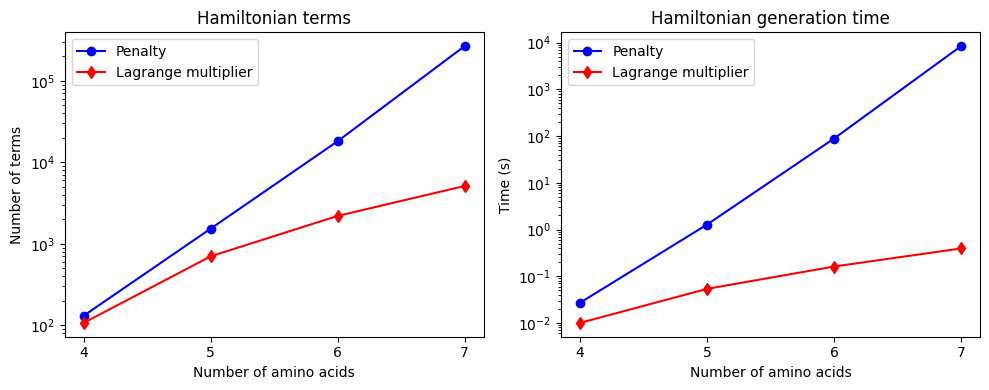

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
num_AAs = range(4, 8)
ax[0].plot(num_AAs, num_ham_terms, marker='o', color='b', label="Penalty")
ax[0].plot(num_AAs, num_ham_terms_lagrange, marker='d', color='r', label="Lagrange multiplier")
ax[0].set_ylabel("Number of terms")
ax[0].set_yscale('log')
ax[0].set_xticks(num_AAs)
ax[0].set_xlabel("Number of amino acids")
ax[0].set_title("Hamiltonian terms")
ax[0].legend()

ax[1].plot(num_AAs, ham_generation_times, marker='o', color='b', label="Penalty")
ax[1].plot(num_AAs, ham_generation_times_lagrange, marker='d', color='r', label="Lagrange multiplier")
ax[1].set_ylabel("Time (s)")
ax[1].set_yscale('log')
ax[1].set_xticks(num_AAs)
ax[1].set_xlabel("Number of amino acids")
ax[1].set_title("Hamiltonian generation time")
ax[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Using optimized compose function
mj_interaction = MiyazawaJerniganInteraction()
penalty_back = 50
penalty_redun = 50
penalty_olap = 50

penalties = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)
penalties_lagrange = PenaltyParameters(penalty_back, penalty_redun)

main_seq_4 = "LFLF" # 6MVZ ("LFLF")
main_seq_5 = "LGKAT" # made up
main_seq_6 = "DEGKAT" # made up
main_seq_7 = "LHPGAGK" # Zika
# main_seq_8 = "YQFWKNFQ"

num_ham_terms = []
num_ham_terms_lagrange = []
ham_generation_times = []
ham_generation_times_lagrange = []
for main_seq in [main_seq_4, main_seq_5, main_seq_6, main_seq_7]:
    print(f"main_seq = {main_seq}")
    peptide = Peptide(main_seq)
    problem = ProteinFoldingProblem(peptide, mj_interaction, penalties)
    problem_lagrange = ProteinFoldingProblem(peptide, mj_interaction, penalties_lagrange)
    start = time()
    qubit_op = problem.qubit_op(r2_threshold=0.99, chunk=20)
    ham_generation_times.append(time() - start)
    print(f"ham_generation_time = {time() - start}")
    num_ham_terms.append(len(qubit_op))
    print(f"num_ham_terms = {len(qubit_op)}")
    start = time()
    qubit_op_lagrange = problem_lagrange.qubit_op()
    ham_generation_times_lagrange.append(time() - start)
    print(f"ham_generation_time_lagrange = {time() - start}")
    num_ham_terms_lagrange.append(len(qubit_op_lagrange))
    print(f"num_ham_terms_lagrange = {len(qubit_op_lagrange)}")
    print()

main_seq = LFLF
Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time to do composition @ k = 2: 0.0002727508544921875
h_op size @ k = 2: 60
Time to do composition @ k = 3: 0.0002658367156982422
h_op size @ k = 3: 62
Time to do composition @ k = 4: 0.00026106834411621094
h_op size @ k = 4: 64
Time to do composition @ k = 5: 0.0002791881561279297
h_op size @ k = 5: 64
Time to do composition @ k = 6: 0.00028586387634277344
h_op size @ k = 6: 64
ham_generation_time = 0.01517486572265625
num_ham_terms = 131
ham_generation_time_lagrange = 0.00964498519897461
num_ham_terms_lagrange = 107

main_seq = LGKAT
Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time to do composition @ k = 2: 0.00046181678771972656
h_op size @ k = 2: 60
Time to do composition @ k = 3: 0.0002808570861816406
h_op size @ k = 3: 62
Time to do composition @ k = 4: 0.00026106834411621094
h_op size @ k = 4: 64
Time to do composition @ k = 5: 0.0003960132598876953
h_op size @ k = 5: 64
Time to do composition @

/Users/ruihaoli/protein-folding-qc/notebooks/../fcc/fcc_qubit_op_builder.py:307: SyntaxWarning: invalid escape sequence '\l'
  Creates qubit operators for the constraints that penalize overlapping


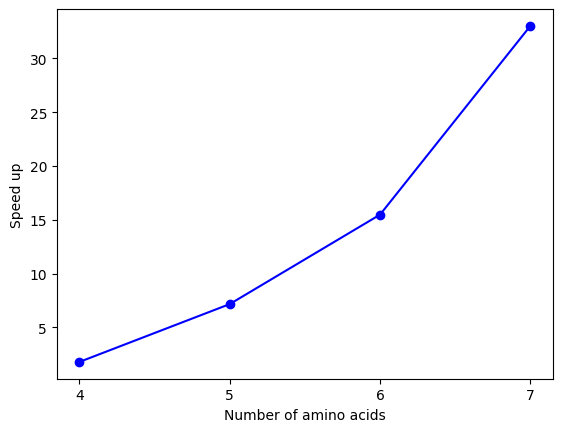

In [6]:
old_ham_generation_times = [0.027128934860229492, 1.2764856815338135, 88.28561615943909, 8384.583355903625]
speed_ups = [old / new for old, new in zip(old_ham_generation_times, ham_generation_times)]

plt.plot(range(4, 8), speed_ups, marker='o', color='b')
plt.xticks(range(4, 8))
plt.xlabel("Number of amino acids")
plt.ylabel("Speed up")

plt.show()

In [7]:
print(ham_generation_times)

[0.01517486572265625, 0.17820119857788086, 5.704680919647217, 253.97946619987488]


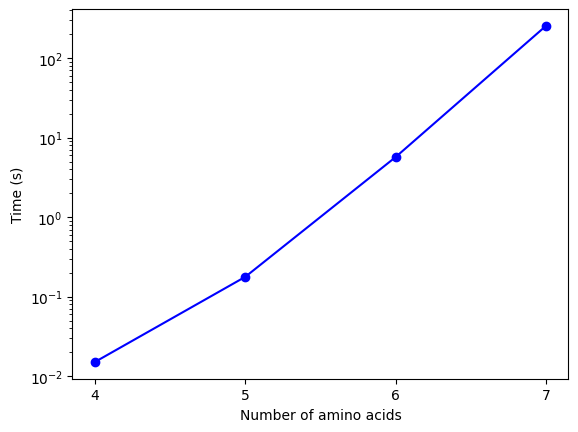

In [8]:
new_ham_generation_times = [0.01517486572265625, 0.17820119857788086, 5.704680919647217, 253.97946619987488]

plt.plot(range(4, 8), new_ham_generation_times, marker='o', color='b')
plt.yscale('log')
plt.xticks(range(4, 8))
plt.xlabel("Number of amino acids")
plt.ylabel("Time (s)")
plt.show()

a = 3.26422337277928, b = -17.6118326389828


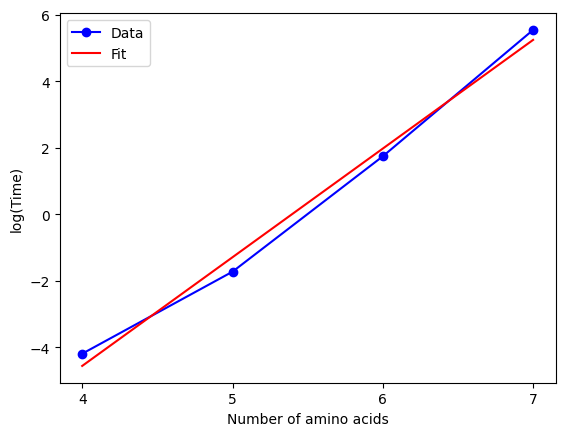

In [9]:
# Fit a linear model to the log of the new ham generation times (y = A + B log x)
a, b = np.polyfit(range(4, 8), np.log(new_ham_generation_times), 1)
print(f"a = {a}, b = {b}")

# Plot the log of the new ham generation times and the linear fit
plt.plot(range(4, 8), np.log(new_ham_generation_times), marker='o', color='b')
plt.plot(range(4, 8), a * np.array(range(4, 8)) + b, color='r')
plt.xticks(range(4, 8))
plt.xlabel("Number of amino acids")
plt.ylabel("log(Time)")
plt.legend(["Data", "Fit"])
plt.show()